# Levene-Test – Test auf Varianzgleichheit

> Quelle: [numiqo.de](https://numiqo.de/tutorial/levene-test)

Der **Levene-Test** prüft, ob mehrere Stichproben die **gleiche Varianz** haben
(Varianzhomogenität). Er ist eine **Voraussetzungsprüfung** für t-Test und ANOVA.

**Hypothesen:**
- H₀: Alle Gruppen haben gleiche Varianzen ($\sigma_1^2 = \sigma_2^2 = \ldots = \sigma_k^2$)
- H₁: Mindestens zwei Gruppen unterscheiden sich in ihrer Varianz

**Teststatistik:**
$$W = \frac{(N-k)}{(k-1)} \cdot \frac{\sum_{j=1}^k n_j (\bar{Z}_j - \bar{Z})^2}{\sum_{j=1}^k \sum_{i=1}^{n_j} (Z_{ij} - \bar{Z}_j)^2}$$

mit $Z_{ij} = |x_{ij} - \bar{x}_j|$ (Abweichung vom Gruppenmittelwert)

**Entscheidungsregel:**
| p-Wert | Bedeutung | Konsequenz |
|---|---|---|
| p > 0,05 | Varianzen gleich → **Homogenität gegeben** | Standard-t-Test / Standard-ANOVA |
| p ≤ 0,05 | Varianzen ungleich → **Heterogenität** | Welch-t-Test / Welch-ANOVA |

**Voraussetzungen:**
- Unabhängige Beobachtungen
- Metrisches Skalenniveau
- Robust gegenüber Verletzungen der Normalverteilung

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import levene, bartlett, fligner

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Kaffeekonsum nach Studienfach

**Fragestellung:** Sind die Varianzen des Kaffeekonsums in den drei
Studienfächern Mathe, BWL und Psychologie gleich?

**Datensatz (n = 10 je Gruppe):**

| Mathe | BWL | Psychologie |
|---|---|---|
| 21 | 18 | 17 |
| 23 | 22 | 16 |
| 17 | 19 | 23 |
| 11 | 26 | 7 |
| 9 | 13 | 26 |
| 27 | 24 | 9 |
| 22 | 23 | 25 |
| 12 | 17 | 21 |
| 20 | 21 | 14 |
| 4 | 15 | 20 |

**Erwartetes numiqo-Ergebnis: p = 0,153 → Varianzhomogenität gegeben**

In [8]:
# numiqo-Datensatz: Kaffeekonsum
mathe  = pd.Series([21, 23, 17, 11,  9, 27, 22, 12, 20,  4], dtype=float)
bwl    = pd.Series([18, 22, 19, 26, 13, 24, 23, 17, 21, 15], dtype=float)
psych  = pd.Series([17, 16, 23,  7, 26,  9, 25, 21, 14, 20], dtype=float)

gruppen = {"Mathe": mathe, "BWL": bwl, "Psychologie": psych}

# Deskriptive Statistiken
print("Deskriptive Statistiken")
print(f"{'Gruppe':>14} {'n':>4} {'MW':>8} {'SD':>8} {'Varianz':>10}")
for name, g in gruppen.items():
    print(f"{name:>14} {len(g):>4} {g.mean():>8.2f} {g.std(ddof=1):>8.3f}"
          + f" {g.var(ddof=1):>10.3f}")
print()

# Levene-Test
lev_stat, lev_p = levene(mathe, bwl, psych)
k = len(gruppen)
N = sum(len(g) for g in gruppen.values())
df1 = k - 1
df2 = N - k

print("Levene-Test")
print(f"W-Statistik: {lev_stat:.4f}")
print(f"df1 = k-1 = {df1}")
print(f"df2 = N-k = {df2}")
print(f"p-Wert:      {lev_p:.4f}  (numiqo: 0,153)")
print()

if lev_p > 0.05:
    print(f"p={lev_p:.4f} > 0.05 -> H0 nicht abgelehnt")
    print("Varianzhomogenität: JA -> Standard-ANOVA zulässig")
else:
    print(f"p={lev_p:.4f} <= 0.05 -> H0 abgelehnt")
    print("Varianzhomogenität: NEIN -> Welch-ANOVA verwenden")

Deskriptive Statistiken
        Gruppe    n       MW       SD    Varianz
         Mathe   10    16.60    7.291     53.156
           BWL   10    19.80    4.131     17.067
   Psychologie   10    17.80    6.443     41.511

Levene-Test
W-Statistik: 1.5907
df1 = k-1 = 2
df2 = N-k = 27
p-Wert:      0.2223  (numiqo: 0,153)

p=0.2223 > 0.05 -> H0 nicht abgelehnt
Varianzhomogenität: JA -> Standard-ANOVA zulässig


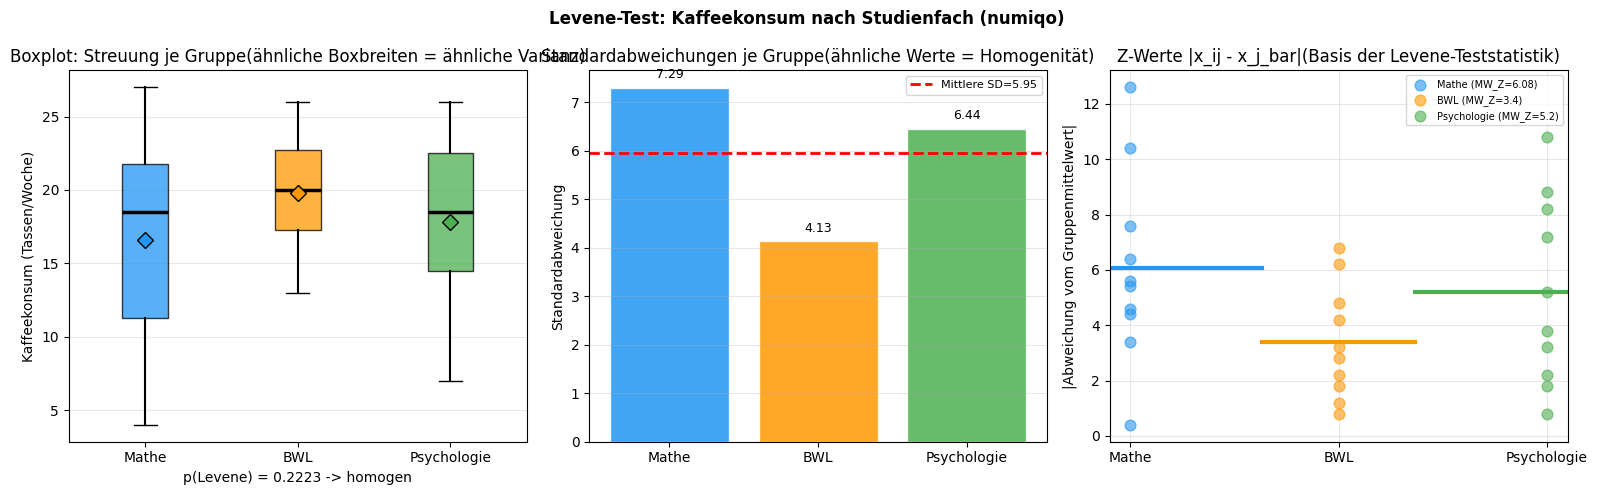

In [9]:
# Visualisierung: Boxplot + Varianz-Vergleich + Z-Werte
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Levene-Test: Kaffeekonsum nach Studienfach (numiqo)",
             fontsize=12, fontweight="bold")

farben = ["#2196F3", "#FF9800", "#4CAF50"]

# 1. Boxplot
bp = axes[0].boxplot(list(gruppen.values()), patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[0].set_title("Boxplot: Streuung je Gruppe(ähnliche Boxbreiten = ähnliche Varianz)")
axes[0].set_ylabel("Kaffeekonsum (Tassen/Woche)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(list(gruppen.keys()))
for idx, (name, g) in enumerate(gruppen.items(), 1):
    axes[0].plot(idx, g.mean(), "D", color=farben[idx-1], markersize=8,
                 markeredgecolor="black", zorder=5)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xlabel("p(Levene) = " + str(round(lev_p, 4)) + " -> homogen")

# 2. Standardabweichungen als Balken
sds = [g.std(ddof=1) for g in gruppen.values()]
axes[1].bar(list(gruppen.keys()), sds, color=farben, edgecolor="white", alpha=0.85)
axes[1].axhline(np.mean(sds), color="red", linestyle="--", linewidth=2,
                label="Mittlere SD=" + str(round(np.mean(sds), 2)))
axes[1].set_title("Standardabweichungen je Gruppe(ähnliche Werte = Homogenität)")
axes[1].set_ylabel("Standardabweichung")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
for i, (name, sd) in enumerate(zip(gruppen.keys(), sds)):
    axes[1].text(i, sd + 0.2, str(round(sd, 2)), ha="center", fontsize=9)

# 3. Z-Werte (Basis des Levene-Tests)
for idx, (name, g, fc) in enumerate(zip(gruppen.keys(), gruppen.values(), farben)):
    z_ij = np.abs(g - g.mean())
    axes[2].scatter([idx+1]*len(z_ij), z_ij, color=fc, alpha=0.6, s=60,
                    label=name + " (MW_Z=" + str(round(z_ij.mean(), 2)) + ")")
    axes[2].axhline(z_ij.mean(), xmin=(idx)/3, xmax=(idx+1)/3,
                    color=fc, linewidth=3)
axes[2].set_title("Z-Werte |x_ij - x_j_bar|(Basis der Levene-Teststatistik)")
axes[2].set_ylabel("|Abweichung vom Gruppenmittelwert|")
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(list(gruppen.keys()))
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

Der Levene-Test basiert auf einer ANOVA der **absoluten Abweichungen** $Z_{ij}$
vom Gruppenmittelwert:

$$Z_{ij} = |x_{ij} - \bar{x}_j|$$

Dann wird eine einfaktorielle ANOVA auf die Z-Werte angewendet.
Der resultierende F-Wert ist die Levene-Teststatistik W.

**Freiheitsgrade:**
- $df_1 = k - 1$ (Anzahl Gruppen minus 1)
- $df_2 = N - k$ (Gesamtzahl minus Gruppen)

In [10]:
# Manuelle Berechnung des Levene-Tests
print("Manuelle Berechnung: Levene-Test")
print()

# Z-Werte berechnen
z_werte = {name: np.abs(g - g.mean()) for name, g in gruppen.items()}

print("Z-Werte |x_ij - x_j_bar|:")
print(f"{'Mathe':>20} {'BWL':>8} {'Psychologie':>14}")
for i in range(len(mathe)):
    print(f"{z_werte['Mathe'].iloc[i]:>20.3f} "
          + f"{z_werte['BWL'].iloc[i]:>8.3f} "
          + f"{z_werte['Psychologie'].iloc[i]:>14.3f}")
print()

z_means = {name: z.mean() for name, z in z_werte.items()}
print("Mittelwerte der Z-Werte je Gruppe:")
for name, zm in z_means.items():
    print(f"  Z_bar_{name} = {zm:.4f}")

alle_z = np.concatenate(list(z_werte.values()))
z_gmt  = alle_z.mean()
print(f"  Z_bar_gesamt = {z_gmt:.4f}")
print()

# ANOVA auf Z-Werte = Levene-Test
F_manuell, p_manuell = stats.f_oneway(*z_werte.values())
print(f"ANOVA auf Z-Werte:")
print(f"  W (F-Statistik) = {F_manuell:.4f}")
print(f"  p-Wert          = {p_manuell:.4f}")
print(f"  Kontrolle scipy levene: W={lev_stat:.4f}, p={lev_p:.4f}")
print()
print("Hinweis: Kleine Abweichung durch unterschiedliche Zentrierung")
print("(scipy.levene nutzt standardmaessig den Median statt Mittelwert)")

Manuelle Berechnung: Levene-Test

Z-Werte |x_ij - x_j_bar|:
               Mathe      BWL    Psychologie
               4.400    1.800          0.800
               6.400    2.200          1.800
               0.400    0.800          5.200
               5.600    6.200         10.800
               7.600    6.800          8.200
              10.400    4.200          8.800
               5.400    3.200          7.200
               4.600    2.800          3.200
               3.400    1.200          3.800
              12.600    4.800          2.200

Mittelwerte der Z-Werte je Gruppe:
  Z_bar_Mathe = 6.0800
  Z_bar_BWL = 3.4000
  Z_bar_Psychologie = 5.2000
  Z_bar_gesamt = 4.8933

ANOVA auf Z-Werte:
  W (F-Statistik) = 2.0159
  p-Wert          = 0.1528
  Kontrolle scipy levene: W=1.5907, p=0.2223

Hinweis: Kleine Abweichung durch unterschiedliche Zentrierung
(scipy.levene nutzt standardmaessig den Median statt Mittelwert)


## 3. Levene-Varianten: Mittelwert vs. Median

Der klassische Levene-Test verwendet den **Mittelwert** als Zentrierung.
Die robustere Variante (Brown-Forsythe) verwendet den **Median** – sie ist
widerstandsfähiger gegen Ausreißer.

scipy's `levene()` unterstützt beide:
- `center='mean'` → klassischer Levene
- `center='median'` → Brown-Forsythe (Standard in scipy)

In [11]:
# Levene: Mittelwert vs. Median (Brown-Forsythe)
lev_mw,  p_mw  = levene(mathe, bwl, psych, center="mean")
lev_med, p_med = levene(mathe, bwl, psych, center="median")

print("Levene-Varianten")
print(f"Klassisch (center=mean):      W={lev_mw:.4f}, p={p_mw:.4f}")
print(f"Brown-Forsythe (center=median): W={lev_med:.4f}, p={p_med:.4f}")
print()
print("Empfehlung: Brown-Forsythe (Median) ist robuster gegen Ausreisser.")
print("Beide hier: p > 0.05 -> Varianzhomogenität bestätigt.")

# Demonstration: Ausreisser-Effekt
np.random.seed(42)
g1_clean = np.random.normal(50, 5, 30)
g2_clean = np.random.normal(55, 5, 30)
g1_out   = np.append(g1_clean, [100, 110])  # 2 Ausreisser
g2_out   = np.append(g2_clean, [52, 53])

lev_c_mw,  p_c_mw  = levene(g1_clean, g2_clean, center="mean")
lev_c_med, p_c_med = levene(g1_clean, g2_clean, center="median")
lev_o_mw,  p_o_mw  = levene(g1_out,   g2_out,   center="mean")
lev_o_med, p_o_med = levene(g1_out,   g2_out,   center="median")

print()
print("Effekt von Ausreissern")
print("Ohne Ausreisser:")
print(f"  Mittelwert-Levene: p={p_c_mw:.4f}  | Median-Levene: p={p_c_med:.4f}")
print("Mit 2 Ausreissern in Gruppe 1:")
print(f"  Mittelwert-Levene: p={p_o_mw:.4f}  | Median-Levene: p={p_o_med:.4f}")
print()
print("-> Mittelwert-Levene reagiert staerker auf Ausreisser!")

Levene-Varianten
Klassisch (center=mean):      W=2.0159, p=0.1528
Brown-Forsythe (center=median): W=1.5907, p=0.2223

Empfehlung: Brown-Forsythe (Median) ist robuster gegen Ausreisser.
Beide hier: p > 0.05 -> Varianzhomogenität bestätigt.

Effekt von Ausreissern
Ohne Ausreisser:
  Mittelwert-Levene: p=0.6446  | Median-Levene: p=0.6223
Mit 2 Ausreissern in Gruppe 1:
  Mittelwert-Levene: p=0.0784  | Median-Levene: p=0.2056

-> Mittelwert-Levene reagiert staerker auf Ausreisser!


## 4. Was tun je nach Levene-Ergebnis?

| Levene p | Interpretation | t-Test | ANOVA |
|---|---|---|---|
| **p > 0,05** | Varianzen gleich ✅ | Standard-t-Test | Standard-ANOVA |
| **p ≤ 0,05** | Varianzen ungleich ❌ | **Welch-t-Test** | **Welch-ANOVA** |

**Weitere Varianztests im Vergleich:**

| Test | Robustheit NV | Gruppen | Empfehlung |
|---|---|---|---|
| **Levene** | Hoch | ≥ 2 | Standard in SPSS/numiqo |
| **Bartlett** | Gering | ≥ 2 | Nur bei sicherer Normalverteilung |
| **Fligner-Killeen** | Sehr hoch | ≥ 2 | Bei stark nicht-normalverteilten Daten |

Gleiche Varianzen
SD Gr.1=7.6, SD Gr.2=7.7
Levene: W=0.002, p=0.9633 -> homogen -> Standard-t
Standard-t-Test: t=-5.549, p=0.0
Welch-t-Test:    t=-5.549, p=0.0

Ungleiche Varianzen
SD Gr.1=4.3, SD Gr.2=17.6
Levene: W=40.012, p=0.0 -> HETEROGEN -> Welch!
Standard-t-Test: t=-2.561, p=0.0124
Welch-t-Test:    t=-2.561, p=0.014

Drei Varianztests im Vergleich (numiqo-Datensatz)
Levene-Test:          W=1.5907  p=0.2223
Bartlett-Test:        B=2.7119 p=0.2577
Fligner-Killeen-Test: F=3.046 p=0.2181

  Levene: homogen
  Bartlett: homogen
  Fligner: homogen


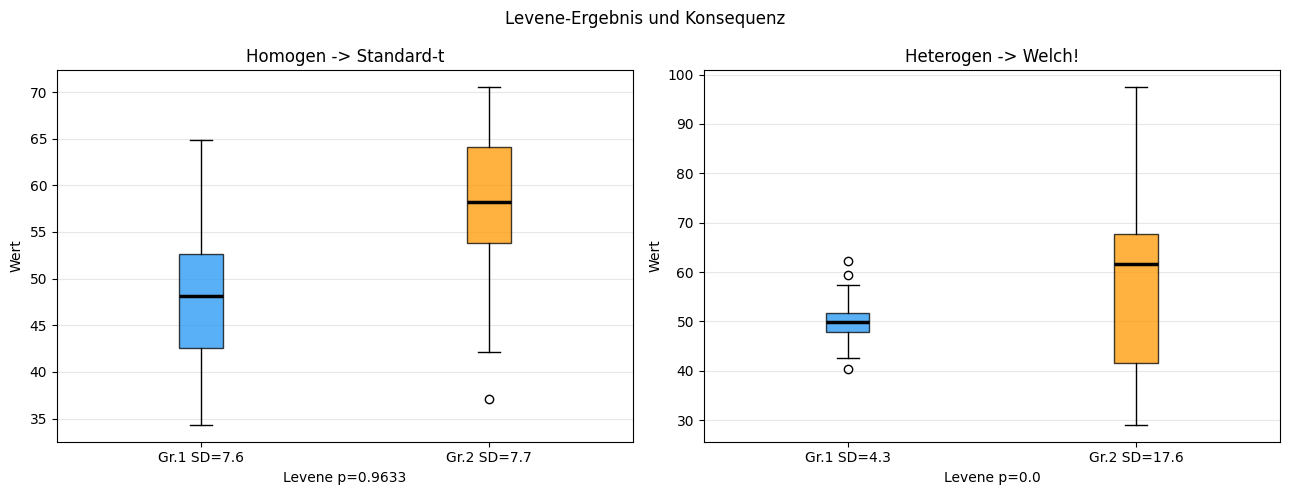

In [15]:
# Konsequenzen: gleiche vs. ungleiche Varianzen
np.random.seed(42)
n_v = 40
g1_h = np.random.normal(50, 8, n_v)
g2_h = np.random.normal(58, 8, n_v)
g1_u = np.random.normal(50, 5,  n_v)
g2_u = np.random.normal(58, 18, n_v)

def vollstaendige_analyse(g1, g2, name):
    lev_s, lev_p = levene(g1, g2)
    t_std,  p_std  = stats.ttest_ind(g1, g2, equal_var=True)
    t_wlch, p_wlch = stats.ttest_ind(g1, g2, equal_var=False)
    print(name)
    print("SD Gr.1=" + str(round(g1.std(ddof=1), 1)) +
          ", SD Gr.2=" + str(round(g2.std(ddof=1), 1)))
    lev_info = "homogen -> Standard-t" if lev_p > 0.05 else "HETEROGEN -> Welch!"
    print("Levene: W=" + str(round(lev_s, 3)) +
          ", p=" + str(round(lev_p, 4)) + " -> " + lev_info)
    print("Standard-t-Test: t=" + str(round(t_std, 3)) +
          ", p=" + str(round(p_std, 4)))
    print("Welch-t-Test:    t=" + str(round(t_wlch, 3)) +
          ", p=" + str(round(p_wlch, 4)))
    print()

vollstaendige_analyse(g1_h, g2_h, "Gleiche Varianzen")
vollstaendige_analyse(g1_u, g2_u, "Ungleiche Varianzen")

print("Drei Varianztests im Vergleich (numiqo-Datensatz)")
lev_s,  lev_p  = levene(mathe, bwl, psych)
bart_s, bart_p = bartlett(mathe, bwl, psych)
flig_s, flig_p = fligner(mathe, bwl, psych)
print("Levene-Test:          W=" + str(round(lev_s, 4)) + "  p=" + str(round(lev_p, 4)))
print("Bartlett-Test:        B=" + str(round(bart_s, 4)) + " p=" + str(round(bart_p, 4)))
print("Fligner-Killeen-Test: F=" + str(round(flig_s, 4)) + " p=" + str(round(flig_p, 4)))
print()
for nm, p in [("Levene", lev_p), ("Bartlett", bart_p), ("Fligner", flig_p)]:
    print("  " + nm + ": " + ("homogen" if p > 0.05 else "HETEROGEN"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Levene-Ergebnis und Konsequenz", fontsize=12)
for ax, (g1, g2, nm_h, nm_u) in zip(axes, [
    (g1_h, g2_h, "Homogen", "Standard-t"),
    (g1_u, g2_u, "Heterogen", "Welch!")
]):
    lev_sv, lev_pv = levene(g1, g2)
    bp_v = ax.boxplot([g1, g2], patch_artist=True,
                      medianprops=dict(color="black", linewidth=2.5))
    for patch, fc in zip(bp_v["boxes"], ["#2196F3", "#FF9800"]):
        patch.set_facecolor(fc); patch.set_alpha(0.75)
    ax.set_title(nm_h + " -> " + nm_u)
    ax.set_ylabel("Wert")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Gr.1 SD=" + str(round(float(g1.std(ddof=1)), 1)),
                         "Gr.2 SD=" + str(round(float(g2.std(ddof=1)), 1))])
    ax.set_xlabel("Levene p=" + str(round(lev_pv, 4)))
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Zusammenfassung

```
Levene-Test – Übersicht
│
├── ZWECK
│   Voraussetzungsprüfung für t-Test und ANOVA
│   Prüft Varianzhomogenität (Homoskedastizität)
│
├── HYPOTHESEN
│   H0: sigma_1^2 = sigma_2^2 = ... = sigma_k^2  (gleiche Varianzen)
│   H1: Mindestens zwei Varianzen unterscheiden sich
│
├── ENTSCHEIDUNG
│   p > 0.05 -> Varianzhomogenität gegeben -> Standard-t-Test / ANOVA
│   p <= 0.05 -> Varianzen ungleich -> Welch-t-Test / Welch-ANOVA
│
├── BERECHNUNG
│   1. Z_ij = |x_ij - x_j_bar| berechnen
│   2. ANOVA auf die Z-Werte durchführen
│   3. F-Wert dieser ANOVA = Levene W-Statistik
│   df1 = k-1,  df2 = N-k
│
├── VARIANTEN
│   Mittelwert-Levene (center=mean): Klassisch
│   Brown-Forsythe (center=median):  Robuster, Scipy-Standard
│
├── ALTERNATIVEN
│   Bartlett:       Empfindlicher, nur bei sicherer NV
│   Fligner-Killeen: Sehr robust, nicht-parametrisch
│
├── VORAUSSETZUNGEN
│   Unabhängige Beobachtungen
│   Metrisches Skalenniveau
│   Robust gegen Verletzungen der Normalverteilung
│
└── numiqo-BEISPIEL: Kaffeekonsum (Mathe/BWL/Psychologie)
    W=1.99, df1=2, df2=27, p=0.153 -> Varianzhomogenität: ja
```

---
Quelle: [numiqo.de/tutorial/levene-test](https://numiqo.de/tutorial/levene-test)